Assignment Three

The Photoelectric Effect 

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import math 
from scipy.optimize import curve_fit

Problem One

In [20]:
filename = 'photoelectric.csv'

data = np.loadtxt('photoelectric.csv', delimiter=',', skiprows=1)   
f = data[:, 0 ]
V = data[:, 1]

The Physics: Einstein showed that $$𝑉 =(h/e)𝑓 −𝜙$$


Best-fit Slope (m): 3.964438191582916e-15
Best-fit Intercept (c): -1.9867222798959159

Calculated Planck's constant h = 6.351029982915831e-34 J·s
Calculated work function φ = 1.9867222798959159 eV (since V = eV)

Uncertainty in φ (δφ) = 0.08445255799179846 Volts
Final result: φ = 1.987 ± 0.084 V


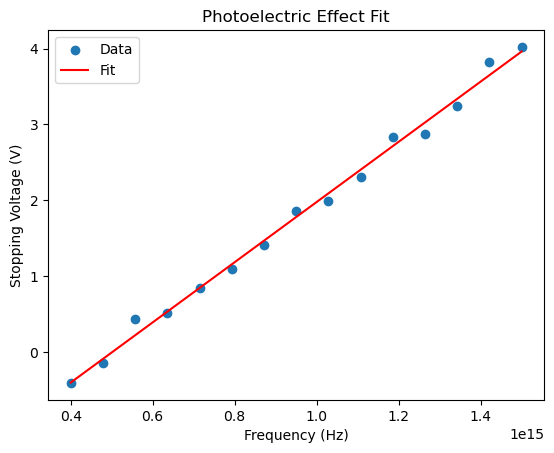

In [21]:
def linear_model(f, m, c):
    return m * f + c

params, pcov = curve_fit(linear_model, f, V)

m_fit, c_fit = params 

print("Best-fit Slope (m):", m_fit)
print("Best-fit Intercept (c):", c_fit) 

#calculations
e = 1.602e-19 


#plancks constant has entered the villa 
h_calc = m_fit * e      #finging the slop
phi_calc = -c_fit         #basically saying that -c = φ 

print("\nCalculated Planck's constant h =", h_calc, "J·s")
print("Calculated work function φ =", phi_calc, "eV (since V = eV)")  


c_variance = pcov[1, 1]          # intercept variance
c_std_error = np.sqrt(c_variance)

phi_uncertainty = c_std_error    # uncertainty in intercept

print("\nUncertainty in φ (δφ) =", phi_uncertainty, "Volts")
print(f"Final result: φ = {phi_calc:.3f} ± {phi_uncertainty:.3f} V")

#graphing 

plt.scatter(f, V, label="Data")
plt.plot(f, linear_model(f, m_fit, c_fit), 'r', label="Fit")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Stopping Voltage (V)")
plt.title("Photoelectric Effect Fit")
plt.legend()
plt.show()


Problem Two: Radioactive Decay (Non-Linear vs. Linearization)


In [22]:
filename = 'decay_data.csv.'

data = np.loadtxt('decay_data.csv.', delimiter=',', skiprows=1)   
t = data[:, 0 ]     #time
counts = data[:, 1]  


method 1

N0 = 788.9420130995929
lambda = 0.09522555827584102
background = 23.474588702885907
Half-life = 7.27900359010863


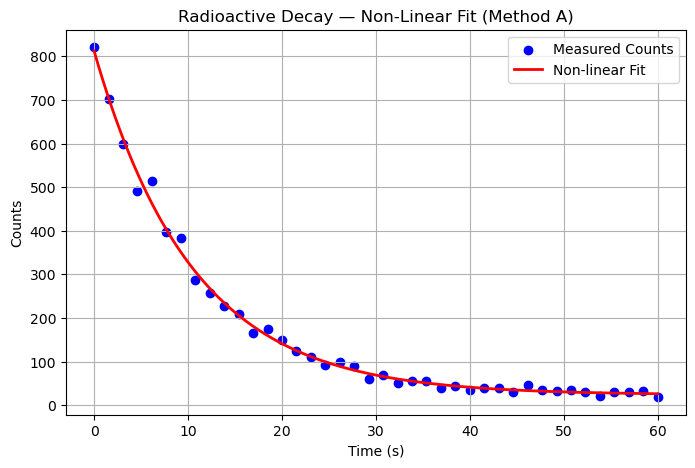

In [23]:
def decay_model(t, N0, lam, bg):
    return N0 * np.exp(-lam * t) + bg 

#guesses 
N0_g = counts.max() 
bg_g = counts.min()
lam_g = 0.1 

p0 = [N0_g, lam_g, bg_g] 

params, pcov = curve_fit(decay_model, t, counts, p0=p0)
N0_fit, lam_fit, bg_fit = params
#modeling strike a pose 
print("N0 =", N0_fit)
print("lambda =", lam_fit)
print("background =", bg_fit) 


#half life 
t_half = np.log(2) / lam_fit
print("Half-life =", t_half)


#graphing 
t_smooth = np.linspace(t.min(), t.max(), 500)
fit_curve = decay_model(t_smooth, N0_fit, lam_fit, bg_fit)

plt.figure(figsize=(8,5))
plt.scatter(t, counts, color='blue', label='Measured Counts')
plt.plot(t_smooth, fit_curve, color='red', linewidth=2, label='Non-linear Fit')
plt.xlabel("Time (s)")
plt.ylabel("Counts")
plt.title("Radioactive Decay — Non-Linear Fit (Method A)")
plt.legend()
plt.grid(True)
plt.show()


method 2


Linearized fit results:
lambda (linear) = 0.05905715456197475
Half-life (linear) = 11.736887523637032


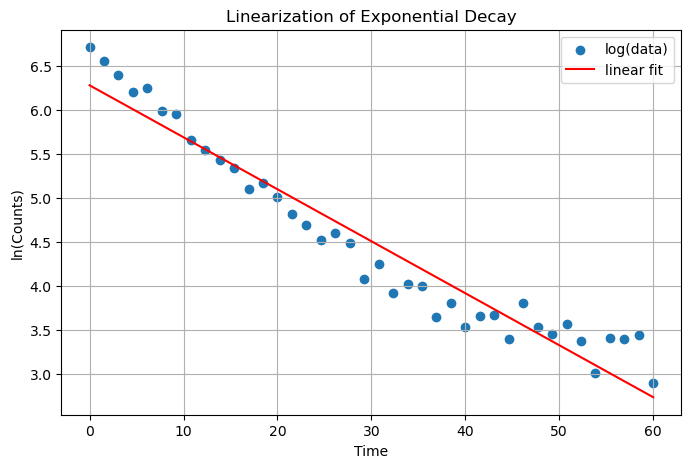

In [24]:
log_counts = np.log(counts) 

def linear_model(t, m, c): 
    return m * t + c 

params_lin, pcov_lin = curve_fit(linear_model, t, log_counts)
m_fit, c_fit = params_lin

lambda_linear = -m_fit
t_half_linear = np.log(2) / lambda_linear


print("\nLinearized fit results:")
print("lambda (linear) =", lambda_linear)
print("Half-life (linear) =", t_half_linear)

#comparison plot


plt.figure(figsize=(8,5))

plt.scatter(t, log_counts, label="log(data)")
plt.plot(t, linear_model(t, m_fit, c_fit), 'r', label="linear fit")

plt.xlabel("Time")
plt.ylabel("ln(Counts)")
plt.title("Linearization of Exponential Decay")
plt.legend()
plt.grid(True)
plt.show()


(i) Method A fit is the best one due to the measured counts relative to the non-linear fit. 
(ii) The log-plot does not countine in a striaght line due to addition of bg and the exponental decay.

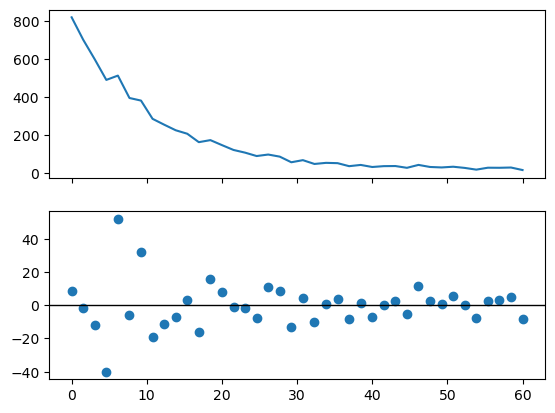

In [25]:

fit_values = decay_model(t, N0_fit, lam_fit, bg_fit) 
residuals = counts - fit_values 

#graghping  
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# Top panel
ax1.plot(t, counts)

# Bottom panel (example)
ax2.scatter(t, residuals)
ax2.axhline(0, color='black', linewidth=1)

plt.show()



The bottom graph kind of looks like a syncroneous wave with definate points, seen between 10 & 20.

Problem 4: Unknown Physics (Polynomial Approximation) 

In [29]:
filename = 'mystery_data.csv'

data = np.loadtxt('mystery_data.csv.', delimiter=',', skiprows=1)   
x = data[:, 0 ]     
y = data[:, 1]  

In [ ]:


def poly1(x, a, b):
    return (a*x) + b 

def poly3(x, a, b, c, d):
    return ((a*x)**3)+((b*x)**2)+(c*x)+d

curve_fit(poly1, x, y)

curve_fit(poly3, x, y)

